In [1]:
!pip install opencv-python yt-dlp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 46.7 MB/s eta 0:00:00


In [ ]:
!pip install opencv-python-headless moviepy

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 1182756-hd_1920_1080_25fps.mp4 to 1182756-hd_1920_1080_25fps.mp4
Saving 8322694-uhd_4096_2160_25fps.mp4 to 8322694-uhd_4096_2160_25fps.mp4


In [ ]:
import cv2
import numpy as np
from google.colab import files
from moviepy.editor import VideoFileClip

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':



In [ ]:
uploaded = files.upload()

Saving 1182756-hd_1920_1080_25fps.mp4 to 1182756-hd_1920_1080_25fps.mp4
Saving 8322694-uhd_4096_2160_25fps.mp4 to 8322694-uhd_4096_2160_25fps.mp4


In [ ]:
def process_video(video_path, output_name):

    cap = cv2.VideoCapture(video_path)

    ret, frame1 = cap.read()
    frame1 = cv2.resize(frame1,(1280,720))
    prvs = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)

    hsv = np.zeros_like(frame1)
    hsv[...,1] = 255

    out = cv2.VideoWriter(output_name,
                          cv2.VideoWriter_fourcc(*'mp4v'),
                          30,
                          (1280,720))

    while True:

        ret, frame2 = cap.read()
        if not ret:
            break

        frame2 = cv2.resize(frame2,(1280,720))
        next = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

        flow = cv2.calcOpticalFlowFarneback(
            prvs,next,None,
            0.5,3,15,3,5,1.2,0)

        mag, ang = cv2.cartToPolar(flow[...,0], flow[...,1])

        hsv[...,0] = ang*180/np.pi/2
        hsv[...,2] = cv2.normalize(mag,None,0,255,cv2.NORM_MINMAX)

        rgb = cv2.cvtColor(hsv,cv2.COLOR_HSV2BGR)

        out.write(rgb)

        prvs = next

    cap.release()
    out.release()

In [ ]:
process_video("blind_man.mp4","blind_man_flow.mp4")
process_video("puppy.mp4","puppy_flow.mp4")

In [ ]:
def track_points(video):

    cap = cv2.VideoCapture(video)

    ret, frame1 = cap.read()
    frame1 = cv2.resize(frame1,(1280,720))
    old_gray = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)

    p0 = cv2.goodFeaturesToTrack(old_gray,
                                 maxCorners=100,
                                 qualityLevel=0.3,
                                 minDistance=7)

    ret, frame2 = cap.read()
    frame2 = cv2.resize(frame2,(1280,720))
    frame_gray = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

    p1, st, err = cv2.calcOpticalFlowPyrLK(
        old_gray,frame_gray,p0,None)

    good_new = p1[st==1]
    good_old = p0[st==1]

    for i,(new,old) in enumerate(zip(good_new,good_old)):

        a,b = new.ravel()
        c,d = old.ravel()

        print("Old:",(c,d)," -> New:",(a,b))

In [ ]:
track_points("blind_man.mp4")
track_points("puppy.mp4")

Old: (np.float32(432.0), np.float32(13.0))  -> New: (np.float32(431.61713), np.float32(12.917659))
Old: (np.float32(959.0), np.float32(9.0))  -> New: (np.float32(958.62646), np.float32(8.668114))
Old: (np.float32(1123.0), np.float32(116.0))  -> New: (np.float32(1122.6995), np.float32(115.63844))
Old: (np.float32(1049.0), np.float32(158.0))  -> New: (np.float32(1048.6929), np.float32(157.64238))
Old: (np.float32(976.0), np.float32(7.0))  -> New: (np.float32(975.67255), np.float32(6.671233))
Old: (np.float32(92.0), np.float32(139.0))  -> New: (np.float32(91.62742), np.float32(139.09856))
Old: (np.float32(1127.0), np.float32(110.0))  -> New: (np.float32(1126.6847), np.float32(109.61986))
Old: (np.float32(339.0), np.float32(2.0))  -> New: (np.float32(338.63266), np.float32(1.9829111))
Old: (np.float32(433.0), np.float32(26.0))  -> New: (np.float32(432.6526), np.float32(25.903334))
Old: (np.float32(233.0), np.float32(24.0))  -> New: (np.float32(232.62589), np.float32(24.03506))
Old: (np.flo

In [ ]:
import cv2
import numpy as np

def visualize_tracking(video):

    cap = cv2.VideoCapture(video)

    ret, frame1 = cap.read()
    frame1 = cv2.resize(frame1,(1280,720))
    gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)

    p0 = cv2.goodFeaturesToTrack(gray1,
                                 maxCorners=100,
                                 qualityLevel=0.3,
                                 minDistance=7)

    ret, frame2 = cap.read()
    frame2 = cv2.resize(frame2,(1280,720))
    gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

    p1, st, err = cv2.calcOpticalFlowPyrLK(gray1,gray2,p0,None)

    good_new = p1[st==1]
    good_old = p0[st==1]

    for new, old in zip(good_new,good_old):

        a,b = new.ravel().astype(int)
        c,d = old.ravel().astype(int)

        cv2.arrowedLine(frame2,(c,d),(a,b),(0,255,0),2)
        cv2.circle(frame2,(a,b),3,(0,0,255),-1)

    cv2.imwrite("tracking_result1.png",frame2)

#visualize_tracking("blind_man.mp4")
visualize_tracking("puppy.mp4")

In [ ]:
from google.colab import files
files.download("tracking_result1.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [7]:
import cv2
from google.colab.patches import cv2_imshow

img = cv2.imread("1.PNG", 0)

orb = cv2.ORB_create()
kp, des = orb.detectAndCompute(img, None)

img_kp = cv2.drawKeypoints(img, kp, None)

#cv2.imshow("Keypoints", img_kp)
cv2.waitKey(0)

-1

In [8]:
img1 = cv2.imread("1.PNG")
img2 = cv2.imread("2.PNG")
img3 = cv2.imread("3.PNG")
img4 = cv2.imread("4.PNG")

# Convert to grayscale
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
gray3 = cv2.cvtColor(img3, cv2.COLOR_BGR2GRAY)
gray4 = cv2.cvtColor(img4, cv2.COLOR_BGR2GRAY)

(np.float64(-0.5), np.float64(419.5), np.float64(376.5), np.float64(-0.5))

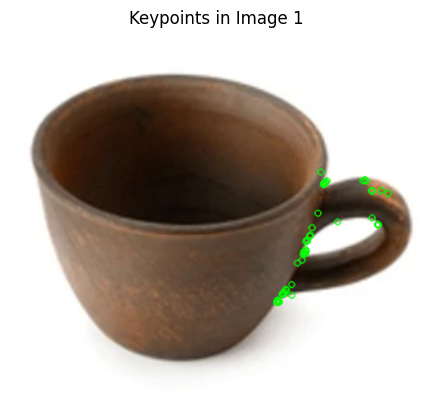

In [11]:
orb = cv2.ORB_create(2000)

kp1, des1 = orb.detectAndCompute(gray1, None)
kp2, des2 = orb.detectAndCompute(gray2, None)
kp3, des3 = orb.detectAndCompute(gray3, None)
kp4, des4 = orb.detectAndCompute(gray4, None)

img_kp = cv2.drawKeypoints(img1, kp1, None, color=(0,255,0))

plt.imshow(cv2.cvtColor(img_kp, cv2.COLOR_BGR2RGB))
plt.title("Keypoints in Image 1")
plt.axis('off')

(np.float64(-0.5), np.float64(856.5), np.float64(376.5), np.float64(-0.5))

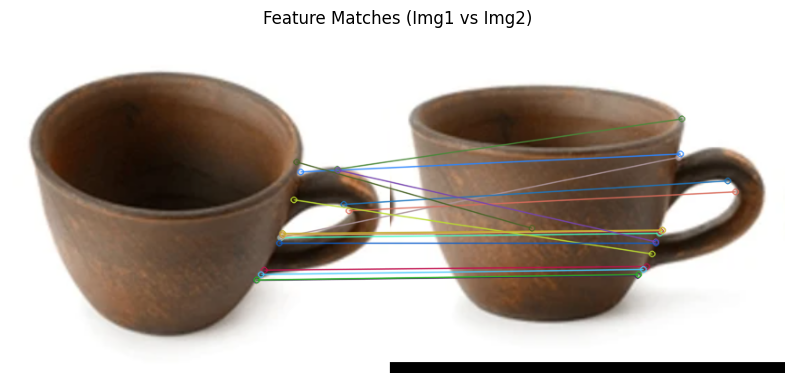

In [12]:
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

matches12 = bf.match(des1, des2)
matches12 = sorted(matches12, key=lambda x: x.distance)

img_matches = cv2.drawMatches(
    img1, kp1,
    img2, kp2,
    matches12[:50],
    None,
    flags=2
)

plt.figure(figsize=(10,5))
plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
plt.title("Feature Matches (Img1 vs Img2)")
plt.axis('off')

In [13]:
pts1 = np.float32([kp1[m.queryIdx].pt for m in matches12]).reshape(-1,1,2)
pts2 = np.float32([kp2[m.trainIdx].pt for m in matches12]).reshape(-1,1,2)

H, mask = cv2.findHomography(pts1, pts2, cv2.RANSAC)

print("Homography Matrix:\n", H)

Homography Matrix:
 [[ 3.13383490e+00  2.09417472e+00 -6.11610190e+02]
 [-4.01670464e-01  3.97536559e+00 -1.83945186e+02]
 [ 7.74683370e-04  6.40089048e-03  1.00000000e+00]]


(np.float64(-0.5), np.float64(436.5), np.float64(364.5), np.float64(-0.5))

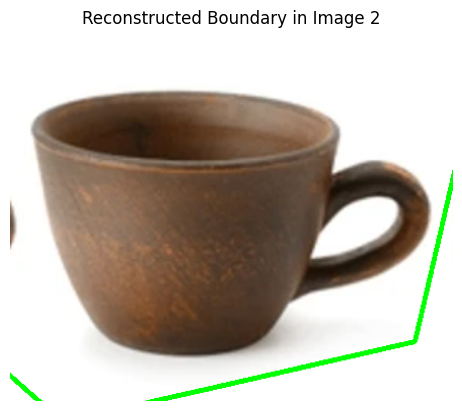

In [17]:
h, w, _ = img1.shape

# Define corners of object in image 1
corners = np.float32([
    [0,0],
    [w,0],
    [w,h],
    [0,h]
]).reshape(-1,1,2)

# Transform corners to image 2
projected = cv2.perspectiveTransform(corners, H)

img2_boundary = img2.copy()

cv2.polylines(
    img2_boundary,
    [np.int32(projected)],
    True,
    (0,255,0),
    3
)

plt.imshow(cv2.cvtColor(img2_boundary, cv2.COLOR_BGR2RGB))
plt.title("Reconstructed Boundary in Image 2")
plt.axis('off')

(np.float64(-0.5), np.float64(390.5), np.float64(387.5), np.float64(-0.5))

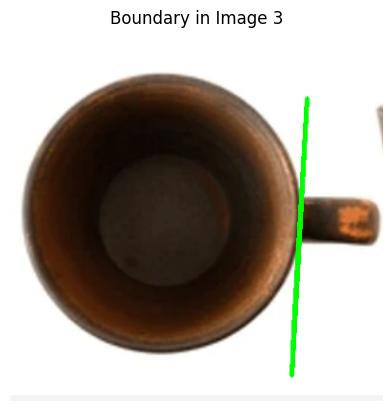

In [15]:
matches13 = bf.match(des1, des3)
matches13 = sorted(matches13, key=lambda x: x.distance)

pts1_13 = np.float32([kp1[m.queryIdx].pt for m in matches13]).reshape(-1,1,2)
pts3 = np.float32([kp3[m.trainIdx].pt for m in matches13]).reshape(-1,1,2)

H13, _ = cv2.findHomography(pts1_13, pts3, cv2.RANSAC)

projected13 = cv2.perspectiveTransform(corners, H13)

img3_boundary = img3.copy()
cv2.polylines(img3_boundary, [np.int32(projected13)], True, (0,255,0), 3)

plt.imshow(cv2.cvtColor(img3_boundary, cv2.COLOR_BGR2RGB))
plt.title("Boundary in Image 3")
plt.axis('off')

(np.float64(-0.5), np.float64(421.5), np.float64(380.5), np.float64(-0.5))

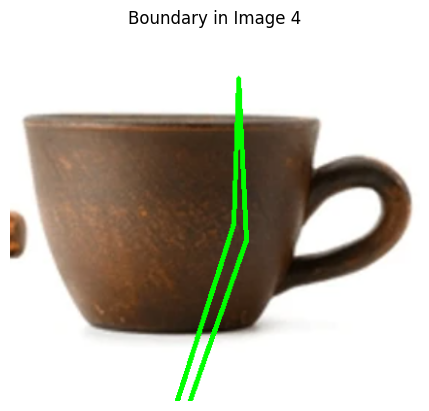

In [16]:
matches14 = bf.match(des1, des4)
matches14 = sorted(matches14, key=lambda x: x.distance)

pts1_14 = np.float32([kp1[m.queryIdx].pt for m in matches14]).reshape(-1,1,2)
pts4 = np.float32([kp4[m.trainIdx].pt for m in matches14]).reshape(-1,1,2)

H14, _ = cv2.findHomography(pts1_14, pts4, cv2.RANSAC)

projected14 = cv2.perspectiveTransform(corners, H14)

img4_boundary = img4.copy()
cv2.polylines(img4_boundary, [np.int32(projected14)], True, (0,255,0), 3)

plt.imshow(cv2.cvtColor(img4_boundary, cv2.COLOR_BGR2RGB))
plt.title("Boundary in Image 4")
plt.axis('off')